# Brownian Motion

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from pathlib import Path

out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "brownian_path.pdf"

### Colab setup

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} fetch origin
        !git -C {repo_dir} reset --hard origin/main

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\ofurn\Dokumenter\Github\fys5429\code\notebooks


### Global parameters

In [3]:
# Answer to the universe and everything
rng = np.random.default_rng(42)

# Input parameters 
S0 = 100.0
mu = 0.05
sigma = 0.2
T = 1.0
n_steps = 1000

### Making some Brownian motion

##### $$S_t = S_0 \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)t + \sigma\, W_t\right], \qquad W_t \sim \mathcal{N}(0, t)$$

In [4]:
# Calculate Geometric Brownian Motion
dt = T / n_steps
t = np.linspace(0.0, T, n_steps + 1)
n_paths = 100

# Generate random increments (n_paths x n_steps)
dW = rng.normal(0, np.sqrt(dt), (n_paths, n_steps))

# Calculate log returns and cumulate
log_returns = (mu - 0.5 * sigma**2) * dt + sigma * dW
S = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), np.cumsum(log_returns, axis=1)]))

### Plotting

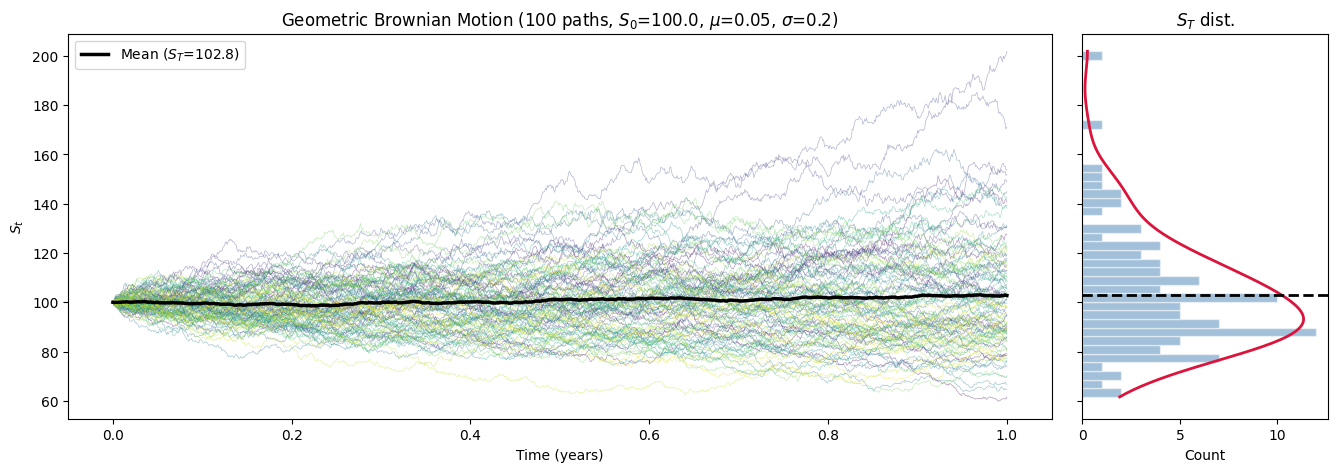

In [5]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax_paths = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_paths)

colors = plt.cm.viridis(np.linspace(0, 1, n_paths))
for i in range(n_paths):
    ax_paths.plot(t, S[i], lw=0.5, alpha=0.4, color=colors[i], rasterized=True)

mean_path = np.mean(S, axis=0)
ax_paths.plot(t, mean_path, lw=2.5, color='black', label=f'Mean ($S_T$={mean_path[-1]:.1f})', rasterized=True)

ax_paths.set_title(f'Geometric Brownian Motion ({n_paths} paths, $S_0$={S0}, $\\mu$={mu}, $\\sigma$={sigma})')
ax_paths.set_xlabel('Time (years)')
ax_paths.set_ylabel('$S_t$')
ax_paths.legend(loc='upper left')

terminal = S[:, -1]
ax_hist.hist(terminal, bins=40, orientation='horizontal', color='steelblue', alpha=0.5, edgecolor='white')
kde = gaussian_kde(terminal)
y_range = np.linspace(terminal.min(), terminal.max(), 200)
kde_vals = kde(y_range)
kde_scaled = kde_vals / kde_vals.max() * ax_hist.get_xlim()[1] * 0.9
ax_hist.plot(kde_scaled, y_range, color='crimson', lw=2)
ax_hist.axhline(np.mean(terminal), color='black', lw=2, linestyle='--')
ax_hist.set_xlabel('Count')
ax_hist.tick_params(labelleft=False)
ax_hist.set_title('$S_T$ dist.')

fig.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.13)
plt.savefig(out_path, bbox_inches="tight")
plt.show()

In [6]:
### Saving to Google Drive

In [7]:
if IN_COLAB:
    from google.colab import drive
    import shutil

    drive.mount('/content/drive')

    drive_dest = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/")
    drive_dest.mkdir(parents=True, exist_ok=True)

    if out_path.exists():
        shutil.copy2(out_path, drive_dest / "brownian_path.pdf")
        print(f"Copied: brownian_path.pdf -> {drive_dest / 'brownian_path.pdf'}")
    else:
        print(f"Not found: {out_path}")
else:
    print(f"PDF saved locally to: {out_path.resolve()}")

PDF saved locally to: C:\Users\ofurn\Dokumenter\Github\fys5429\code\plots\eda\brownian_path.pdf
